# Cross-Domain Robustness Testing — UQ v2

**Mục tiêu**: Kiểm tra sức đề kháng của hệ thống IDS đã train (frozen) trên dataset **NF-UQ-NIDS v2** mà model chưa từng thấy.

**Nguyên tắc**:
- Base Models (CNN+LSTM, TL-BiLSTM, Transformer): **Đóng băng hoàn toàn**
- Meta-Learner (Logistic Regression): **Đóng băng hoàn toàn**
- Chỉ cho phép tạo "cây cầu" (Feature Extractor mới) để chuyển UQ v2 → Không gian ẩn 64 chiều

**2 Kịch bản Test**:
1. **Zero-Shot Transfer**: Chạy thẳng qua pipeline cũ → Baseline
2. **Semi-Supervised Few-Shot**: Fine-tune Feature Extractor với 1-5% dữ liệu có nhãn

**Feature Gap**: UQ v2 có 39 features, UQ v3 (training) có 47 features (thiếu 8 IAT features)

In [1]:
import sys, os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Function
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from copy import deepcopy
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from feature_alignment import (
    FeatureAligner, UQFeatureExtractor, CICFeatureExtractor,
    create_sessions_and_windows, fit_scaler, apply_scaler, encode_labels,
    TimeSeriesDataset, create_dataloaders,
    DEVICE, LATENT_DIM, WINDOW_SIZE, STRIDE, NUM_CLASSES, UNIFIED_CLASSES,
    UQ_LABEL_MAP, UQ_SESSION_COLS,
)

# ============================================================
# CONSTANTS
# ============================================================
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))
MODEL_DIR = os.path.join(BASE_DIR, "Project", "Model", "Model_2017_IRM")

V2_DATA_PATH = os.path.join(BASE_DIR, "Dataset", "nf_uq_balanced_dataset.parquet")
V3_DATA_PATH = os.path.join(BASE_DIR, "Dataset", "nf_uq_balanced_dataset_v3.parquet")

MODEL_NAMES = ['cnn_lstm', 'tl_bilstm', 'transformer']
BATCH_SIZE = 256

# V2 label mapping (slightly different from v3)
V2_LABEL_MAP = {
    'Benign': 'Benign',
    'BruteForce': 'BruteForce',
    'DDoS': 'DDoS',
    'DoS': 'DoS',
    'Infiltration': 'Infiltration',
}

# 8 IAT features present in V3 but missing in V2
V3_ONLY_FEATURES = [
    'SRC_TO_DST_IAT_MIN', 'SRC_TO_DST_IAT_MAX',
    'SRC_TO_DST_IAT_AVG', 'SRC_TO_DST_IAT_STDDEV',
    'DST_TO_SRC_IAT_MIN', 'DST_TO_SRC_IAT_MAX',
    'DST_TO_SRC_IAT_AVG', 'DST_TO_SRC_IAT_STDDEV',
]

print(f"Device: {DEVICE}")
print(f"Latent Dim: {LATENT_DIM}, Window Size: {WINDOW_SIZE}")
print(f"Classes: {UNIFIED_CLASSES}")
print(f"Model Dir: {MODEL_DIR}")

Device: cuda
Latent Dim: 64, Window Size: 30
Classes: ['Benign', 'BruteForce', 'DDoS', 'DoS', 'Infiltration']
Model Dir: /home/huyho/earth_predict_env/Project/Model/Model_2017_IRM


## 1. Define Model Architectures & Load Frozen Models

Tất cả base models và meta-learner đều **đóng băng hoàn toàn** (`requires_grad=False`).  
Kiến trúc phải giống 100% với lúc train trong `Meta_Learner.ipynb`.

In [2]:
# ================================================================
# Model Architectures (identical to Meta_Learner.ipynb)
# ================================================================

class CNN_LSTM(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, num_classes=NUM_CLASSES):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(latent_dim, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
        )
        self.lstm = nn.LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3)
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(128, num_classes))

    def forward(self, z):
        x = z.permute(0, 2, 1)
        x = self.cnn(x).permute(0, 2, 1)
        _, (h_n, _) = self.lstm(x)
        return self.classifier(h_n[-1])


class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2), nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, lstm_output):
        attn_weights = torch.softmax(self.attention(lstm_output), dim=1)
        return (lstm_output * attn_weights).sum(dim=1), attn_weights.squeeze(-1)


class TL_BiLSTM(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=128, num_classes=NUM_CLASSES):
        super().__init__()
        self.bilstm = nn.LSTM(latent_dim, hidden_dim // 2, num_layers=2,
                              batch_first=True, dropout=0.3, bidirectional=True)
        self.attention = TemporalAttention(hidden_dim)
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(hidden_dim, num_classes))

    def forward(self, z):
        lstm_out, _ = self.bilstm(z)
        context, _ = self.attention(lstm_out)
        return self.classifier(self.layer_norm(context))


class TransformerClassifier(nn.Module):
    def __init__(self, d_model=LATENT_DIM, nhead=8, num_layers=4,
                 dim_feedforward=256, num_classes=NUM_CLASSES):
        super().__init__()
        self.pos_enc = nn.Parameter(torch.randn(1, WINDOW_SIZE, d_model) * 0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=0.1, batch_first=True, activation='gelu')
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.layer_norm = nn.LayerNorm(d_model)
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(d_model, num_classes))

    def forward(self, z):
        x = z + self.pos_enc[:, :z.size(1), :]
        x = self.layer_norm(self.transformer(x))
        return self.classifier(x.mean(dim=1))


class AlignerWithModel(nn.Module):
    def __init__(self, uq_dim, cic_dim, base_model):
        super().__init__()
        self.aligner = FeatureAligner(uq_dim, cic_dim)
        self.base_model = base_model

    def forward(self, x, dataset_type='uq'):
        z = self.aligner(x, dataset_type)
        return self.base_model(z)

    def predict_proba(self, x, dataset_type='uq'):
        return torch.softmax(self.forward(x, dataset_type), dim=1)


def create_models(uq_dim, cic_dim):
    return {
        'cnn_lstm': AlignerWithModel(uq_dim, cic_dim, CNN_LSTM()),
        'tl_bilstm': AlignerWithModel(uq_dim, cic_dim, TL_BiLSTM()),
        'transformer': AlignerWithModel(uq_dim, cic_dim, TransformerClassifier()),
    }

print("Model architectures defined.")

Model architectures defined.


In [3]:
# ================================================================
# Load Frozen Models
# ================================================================
# UQ v3 = 47 features, CIC = 78 features (as used during training)
UQ_V3_DIM = 47
CIC_DIM = 78

# Create model instances and load saved weights
frozen_models = create_models(UQ_V3_DIM, CIC_DIM)

for name in MODEL_NAMES:
    path = os.path.join(MODEL_DIR, f"final_{name}.pth")
    state_dict = torch.load(path, map_location=DEVICE, weights_only=True)
    frozen_models[name].load_state_dict(state_dict)
    frozen_models[name].to(DEVICE)
    frozen_models[name].eval()
    frozen_models[name].requires_grad_(False)
    n_params = sum(p.numel() for p in frozen_models[name].parameters())
    print(f"✓ Loaded & frozen {name}: {n_params:,} params")

# Load frozen meta-learner
meta_learner = joblib.load(os.path.join(MODEL_DIR, "meta_learner_lr.pkl"))
print(f"✓ Loaded meta-learner: {type(meta_learner).__name__}")

# Extract the frozen UQ Feature Extractor (for reference embeddings)
frozen_uq_extractor = frozen_models['cnn_lstm'].aligner.uq_extractor
print(f"✓ Frozen UQ Feature Extractor: input={UQ_V3_DIM} → output={LATENT_DIM}")

# Verify all parameters are frozen
for name, model in frozen_models.items():
    trainable = sum(p.requires_grad for p in model.parameters())
    assert trainable == 0, f"{name} has {trainable} trainable params!"
print("\n✓ All base models and meta-learner are FROZEN.")

✓ Loaded & frozen cnn_lstm: 364,869 params
✓ Loaded & frozen tl_bilstm: 208,646 params
✓ Loaded & frozen transformer: 235,845 params
✓ Loaded meta-learner: LogisticRegression
✓ Frozen UQ Feature Extractor: input=47 → output=64

✓ All base models and meta-learner are FROZEN.


## 2. Load & Preprocess UQ v2 Test Data

- UQ v2 có 39 features (sau khi drop metadata/session cols)
- UQ v3 (training) có 47 features (39 chung + 8 IAT features)
- Cần xác định mapping feature giữa v2 và v3 cho Zero-Shot test
- Scale riêng bằng StandardScaler mới (phân phối khác)

In [4]:
# ================================================================
# Load UQ v2 Test Dataset
# ================================================================
print("Loading UQ v2 test data...")
v2_df = pd.read_parquet(V2_DATA_PATH)
print(f"Raw shape: {v2_df.shape}")
print(f"Labels: {v2_df['Label'].value_counts().to_dict()}")

# Map labels to unified scheme
v2_df['Label'] = v2_df['Label'].map(V2_LABEL_MAP)
v2_df = v2_df.dropna(subset=['Label'])
print(f"\nAfter label mapping: {v2_df['Label'].value_counts().to_dict()}")

# Extract session cols + labels
v2_labels = v2_df['Label'].copy()
v2_session_keys = v2_df[UQ_SESSION_COLS].copy()

# Drop metadata and non-feature columns
V2_DROP_COLS = ['IPV4_SRC_ADDR', 'IPV4_DST_ADDR', 'Label', 'Dataset']
v2_features = v2_df.drop(columns=[c for c in V2_DROP_COLS if c in v2_df.columns])
v2_feature_cols = [c for c in v2_features.columns if c not in UQ_SESSION_COLS]
print(f"\nV2 feature columns ({len(v2_feature_cols)}): {v2_feature_cols}")

# ================================================================
# Load UQ v3 reference to get feature column order
# ================================================================
print("\nLoading UQ v3 reference for feature mapping...")
v3_df = pd.read_parquet(V3_DATA_PATH, columns=['Label'] + UQ_SESSION_COLS +
    [c for c in pd.read_parquet(V3_DATA_PATH, columns=[]).columns
     if c not in ['IPV4_SRC_ADDR','IPV4_DST_ADDR','FLOW_START_MILLISECONDS',
                  'FLOW_END_MILLISECONDS','Label'] + UQ_SESSION_COLS][:1])

# Get V3 feature order from full column list
v3_all_cols = pd.read_parquet(V3_DATA_PATH).columns.tolist()
V3_DROP_COLS = ['IPV4_SRC_ADDR', 'IPV4_DST_ADDR', 'Label',
                'FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS']
v3_feature_cols = [c for c in v3_all_cols if c not in V3_DROP_COLS + UQ_SESSION_COLS]
print(f"V3 feature columns ({len(v3_feature_cols)}): {v3_feature_cols}")

# Identify common features and their positions
common_features = [c for c in v3_feature_cols if c in v2_feature_cols]
v3_only = [c for c in v3_feature_cols if c not in v2_feature_cols]
print(f"\nCommon features: {len(common_features)}")
print(f"Only in V3 (missing from V2): {len(v3_only)} → {v3_only}")
del v3_df  # free memory

Loading UQ v2 test data...
Raw shape: (1303456, 54)
Labels: {'Benign': 400000, 'DDoS': 300000, 'DoS': 203456, 'Infiltration': 200000, 'BruteForce': 200000}

After label mapping: {'Benign': 400000, 'DDoS': 300000, 'DoS': 203456, 'Infiltration': 200000, 'BruteForce': 200000}

V2 feature columns (49): ['FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS', 'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS', 'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT', 'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES', 'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES', 'NUM_PKTS_1024_TO_1514_BYTES',

In [5]:
# ================================================================
# Create Sessions & Windows for UQ v2
# ================================================================
print("Creating sessions and sliding windows for UQ v2...")
v2_windows, v2_window_labels = create_sessions_and_windows(
    v2_features, v2_labels, v2_session_keys, v2_feature_cols
)
print(f"V2 windows: {v2_windows.shape}")  # (N, 30, 39)
print(f"Window label distribution:")
for cls in UNIFIED_CLASSES:
    n = (v2_window_labels == cls).sum()
    print(f"  {cls}: {n} ({n/len(v2_window_labels)*100:.1f}%)")

# Scale with NEW scaler (v2 has different distribution)
v2_scaler = fit_scaler(v2_windows)
v2_windows_scaled = apply_scaler(v2_windows, v2_scaler)

# Encode labels
v2_labels_encoded, v2_le = encode_labels(v2_window_labels)
V2_N_FEATURES = v2_windows_scaled.shape[2]  # 39
print(f"\n✓ V2 preprocessed: {v2_windows_scaled.shape}, {V2_N_FEATURES} features")
print(f"  Labels encoded: {np.bincount(v2_labels_encoded)}")

del v2_df, v2_features, v2_labels, v2_session_keys  # free memory

Creating sessions and sliding windows for UQ v2...
V2 windows: (315555, 30, 49)
Window label distribution:
  Benign: 227427 (72.1%)
  BruteForce: 20022 (6.3%)
  DDoS: 23506 (7.4%)
  DoS: 29935 (9.5%)
  Infiltration: 14665 (4.6%)

✓ V2 preprocessed: (315555, 30, 49), 49 features
  Labels encoded: [227427  20022  23506  29935  14665]


## 3. Generate Reference Embeddings from UQ v3

Chạy dữ liệu UQ v3 (training) qua frozen `UQFeatureExtractor` để lấy phân phối chuẩn của không gian ẩn 64 chiều.  
Embeddings này sẽ làm "target" cho MMD alignment ở Test 2 (Semi-Supervised).

In [6]:
%%time
# ================================================================
# Load UQ v3 and generate reference embeddings via frozen extractor
# ================================================================
from feature_alignment import prepare_dataset

print("Loading UQ v3 (training data) for reference embeddings...")
v3_windows_scaled, v3_labels_encoded, v3_scaler, _, v3_n_feat = prepare_dataset('uq')
print(f"V3 windows: {v3_windows_scaled.shape}, {v3_n_feat} features")

# Sample a representative subset for MMD (memory-efficient)
REF_SAMPLE_SIZE = min(15000, len(v3_windows_scaled))
np.random.seed(42)
ref_indices = np.random.choice(len(v3_windows_scaled), REF_SAMPLE_SIZE, replace=False)
v3_ref_windows = v3_windows_scaled[ref_indices]
v3_ref_labels = v3_labels_encoded[ref_indices]

# Generate 64-dim reference embeddings
print(f"\nGenerating reference embeddings from {REF_SAMPLE_SIZE} v3 windows...")
ref_embeddings_list = []
frozen_uq_extractor.eval()

with torch.no_grad():
    ds = TimeSeriesDataset(v3_ref_windows, v3_ref_labels, 'uq')
    loader = DataLoader(ds, batch_size=512, shuffle=False)
    for x, _, _ in loader:
        x = x.to(DEVICE)
        emb = frozen_uq_extractor(x)  # (batch, 30, 64)
        ref_embeddings_list.append(emb.cpu())

ref_embeddings = torch.cat(ref_embeddings_list, dim=0)  # (N_ref, 30, 64)
# Flatten time dimension for MMD: (N_ref * 30, 64)
ref_embeddings_flat = ref_embeddings.reshape(-1, LATENT_DIM)

print(f"✓ Reference embeddings: {ref_embeddings.shape}")
print(f"  Flattened for MMD: {ref_embeddings_flat.shape}")
print(f"  Mean per dim: [{ref_embeddings_flat.mean(0)[:5].numpy()}...]")
print(f"  Std per dim:  [{ref_embeddings_flat.std(0)[:5].numpy()}...]")

# Keep full v3 windows for later use but free the large arrays
v3_full_windows = v3_windows_scaled  # keep reference
v3_full_labels = v3_labels_encoded
print(f"\n✓ Reference data ready for domain adaptation.")

Loading UQ v3 (training data) for reference embeddings...
[UQ] Loaded 1388150 flows, 47 features
[UQ] Label distribution:
Label
Benign          399999
DoS             300000
DDoS            300000
BruteForce      199999
Infiltration    188152
[UQ] Created 186005 windows of shape (186005, 30, 47)
[UQ] Feature dim: 47, Latent target: 64
V3 windows: (186005, 30, 47), 47 features

Generating reference embeddings from 15000 v3 windows...
✓ Reference embeddings: torch.Size([15000, 30, 64])
  Flattened for MMD: torch.Size([450000, 64])
  Mean per dim: [[0.00076042 0.00020378 0.00253439 0.02393277 0.00443059]...]
  Std per dim:  [[0.00671493 0.00401028 0.01258949 0.08028959 0.02496128]...]

✓ Reference data ready for domain adaptation.
CPU times: user 26.8 s, sys: 2.6 s, total: 29.4 s
Wall time: 27.1 s


---

## Test 1: Zero-Shot Transfer (Baseline)

**Bài test khắc nghiệt nhất**: Model gốc phải tự xử lý dữ liệu UQ v2 mà không có bất kỳ sự hỗ trợ nào.

**Cách làm**: 
- Tạo `UQv2FeatureExtractor(39→64)` riêng cho V2
- Khởi tạo bằng **Partial Weight Transfer** từ frozen V3 extractor (copy các layer tương thích, layer đầu khởi tạo riêng)
- Chạy qua frozen pipeline: `V2Extractor(39→64) → 3 Base Models → Meta-Learner`
- **Không padding**, **không dùng V3 extractor trên dữ liệu V2**

**Kỳ vọng**: F1-score sẽ sụt giảm do khác biệt phân phối + V2 extractor chưa được train.

In [7]:
# ================================================================
# Define UQv2 Feature Extractor + Evaluation Functions
# ================================================================
import torch.nn.functional as F

class UQv2FeatureExtractor(nn.Module):
    """Feature Extractor riêng cho UQ v2: 39 features → 64 chiều."""

    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, LATENT_DIM),
            nn.BatchNorm1d(LATENT_DIM),
            nn.ReLU(),
        )

    def forward(self, x):
        # x: (batch, time_steps, input_dim)
        batch, T, D = x.shape
        x_flat = x.reshape(batch * T, D)
        out = self.net(x_flat)
        return out.reshape(batch, T, LATENT_DIM)


def init_v2_extractor_from_v3(v2_extractor, frozen_v3_extractor, v2_feature_cols, v3_feature_cols):
    """
    Partial weight transfer: copy tất cả layers tương thích từ V3 extractor.
    Layer đầu tiên (Linear 47→128 vs 39→128): copy 39 cột trùng feature.
    Các layer còn lại (128→BN→64→BN): copy trực tiếp vì cùng kích thước.
    """
    v3_state = frozen_v3_extractor.state_dict()
    v2_state = v2_extractor.state_dict()

    # Layer 0: Linear(input_dim→128) — weight shape (128, input_dim)
    # V3: (128, 47), V2: (128, 39)
    # Copy columns corresponding to common features
    v3_weight = v3_state['net.0.weight']  # (128, 47)
    v3_bias = v3_state['net.0.bias']      # (128,)

    # Build column mapping: for each v2 feature, find its index in v3
    col_map = []
    for v2_col in v2_feature_cols:
        if v2_col in v3_feature_cols:
            col_map.append(v3_feature_cols.index(v2_col))
        else:
            col_map.append(None)

    mapped = 0
    for v2_idx, v3_idx in enumerate(col_map):
        if v3_idx is not None:
            v2_state['net.0.weight'][:, v2_idx] = v3_weight[:, v3_idx]
            mapped += 1

    v2_state['net.0.bias'] = v3_bias.clone()
    print(f"  Layer 0 (Linear): mapped {mapped}/{len(v2_feature_cols)} columns from V3")

    # Layers 1-6: BN(128), ReLU, Dropout, Linear(128→64), BN(64), ReLU
    # These have same dimensions → direct copy
    layers_to_copy = [
        'net.1.weight', 'net.1.bias', 'net.1.running_mean', 'net.1.running_var',  # BN 128
        'net.4.weight', 'net.4.bias',  # Linear 128→64
        'net.5.weight', 'net.5.bias', 'net.5.running_mean', 'net.5.running_var',  # BN 64
    ]
    copied = 0
    for key in layers_to_copy:
        if key in v3_state and key in v2_state:
            v2_state[key] = v3_state[key].clone()
            copied += 1

    v2_extractor.load_state_dict(v2_state)
    print(f"  Remaining layers: copied {copied} parameter tensors")
    return v2_extractor


# ================================================================
# Create Zero-Shot V2 Extractor with Partial Weight Transfer
# ================================================================
v2_feat_clean = [c for c in v2_feature_cols if c != 'Dataset']

v2_extractor_zs = UQv2FeatureExtractor(V2_N_FEATURES).to(DEVICE)
print("Initializing UQv2FeatureExtractor via Partial Weight Transfer from frozen V3 extractor:")
v2_extractor_zs = init_v2_extractor_from_v3(
    v2_extractor_zs, frozen_uq_extractor, v2_feat_clean, v3_feature_cols
)
v2_extractor_zs.eval()
v2_extractor_zs.requires_grad_(False)

# Verify
with torch.no_grad():
    test_v2 = torch.FloatTensor(v2_windows_scaled[:4]).to(DEVICE)
    test_out = v2_extractor_zs(test_v2)
    print(f"\n✓ V2 extractor test: input {test_v2.shape} → output {test_out.shape}")
    print(f"  Output stats: mean={test_out.mean():.4f}, std={test_out.std():.4f}")


# ================================================================
# Evaluation Functions (shared by all tests)
# ================================================================

@torch.no_grad()
def predict_with_new_extractor(extractor, base_model, windows, batch_size=512):
    """Run V2 data through new extractor → frozen base model."""
    extractor.eval()
    base_model.eval()
    ds = TimeSeriesDataset(windows, np.zeros(len(windows)), 'uq')
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    all_probs = []
    for x, _, _ in loader:
        x = x.to(DEVICE)
        z = extractor(x)  # (batch, 30, 64)
        logits = base_model(z)
        probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
    return np.vstack(all_probs)


def evaluate_with_extractor(extractor, windows, labels, scenario_name=''):
    """Run V2 through new extractor → all frozen base models → meta-learner."""
    print(f"\n{'='*60}")
    print(f"  {scenario_name}")
    print(f"{'='*60}")

    probs_list = []
    for name in MODEL_NAMES:
        print(f"  Running {name}...", end=' ')
        base_model = frozen_models[name].base_model
        probs = predict_with_new_extractor(extractor, base_model, windows)
        probs_list.append(probs)
        acc = (probs.argmax(1) == labels).mean()
        print(f"Acc: {acc:.4f}")

    X_meta = np.hstack(probs_list)
    predictions = meta_learner.predict(X_meta)

    weighted_f1 = f1_score(labels, predictions, average='weighted')
    macro_f1 = f1_score(labels, predictions, average='macro')
    per_class_f1 = f1_score(labels, predictions, average=None, labels=range(NUM_CLASSES))

    print(f"\n  Weighted F1: {weighted_f1:.4f}")
    print(f"  Macro F1:    {macro_f1:.4f}")
    print(f"\n{classification_report(labels, predictions, target_names=UNIFIED_CLASSES, digits=4)}")

    return {
        'predictions': predictions,
        'weighted_f1': weighted_f1,
        'macro_f1': macro_f1,
        'per_class_f1': per_class_f1,
        'X_meta': X_meta,
        'confusion_matrix': confusion_matrix(labels, predictions),
    }


print("\n✓ UQv2FeatureExtractor, evaluation functions defined.")

Initializing UQv2FeatureExtractor via Partial Weight Transfer from frozen V3 extractor:
  Layer 0 (Linear): mapped 47/49 columns from V3
  Remaining layers: copied 10 parameter tensors

✓ V2 extractor test: input torch.Size([4, 30, 49]) → output torch.Size([4, 30, 64])
  Output stats: mean=0.0218, std=0.2825

✓ UQv2FeatureExtractor, evaluation functions defined.


In [8]:
%%time
# ================================================================
# Test 1: Zero-Shot — V2 Extractor (Partial Weight Transfer) → Frozen Pipeline
# ================================================================

results_zeroshot = evaluate_with_extractor(
    v2_extractor_zs, v2_windows_scaled, v2_labels_encoded,
    'TEST 1: Zero-Shot Transfer (Baseline) — UQv2 Extractor'
)
print(f"\n✓ Baseline F1 (Zero-Shot): {results_zeroshot['weighted_f1']:.4f}")


  TEST 1: Zero-Shot Transfer (Baseline) — UQv2 Extractor
  Running cnn_lstm... Acc: 0.5619
  Running tl_bilstm... Acc: 0.7196
  Running transformer... Acc: 0.5086

  Weighted F1: 0.5648
  Macro F1:    0.2172

              precision    recall  f1-score   support

      Benign     0.7408    0.7863    0.7628    227427
  BruteForce     0.0000    0.0000    0.0000     20022
        DDoS     0.0000    0.0000    0.0000     23506
         DoS     0.0000    0.0000    0.0000     29935
Infiltration     0.1935    0.9782    0.3230     14665

    accuracy                         0.6121    315555
   macro avg     0.1868    0.3529    0.2172    315555
weighted avg     0.5429    0.6121    0.5648    315555


✓ Baseline F1 (Zero-Shot): 0.5648
CPU times: user 17 s, sys: 444 ms, total: 17.5 s
Wall time: 15.4 s


In [9]:
# ================================================================
# Define MMD Utilities (for Test 2 Semi-Supervised)
# ================================================================

def gaussian_kernel(x, y, sigmas=None):
    """Compute Gaussian RBF kernel matrix between x and y."""
    if sigmas is None:
        sigmas = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
    xx = (x * x).sum(dim=1, keepdim=True)
    yy = (y * y).sum(dim=1, keepdim=True)
    dist_sq = xx + yy.t() - 2.0 * x @ y.t()
    dist_sq = torch.clamp(dist_sq, min=0.0)

    kernel_val = torch.zeros_like(dist_sq)
    for sigma in sigmas:
        gamma = 1.0 / (2.0 * sigma ** 2)
        kernel_val = kernel_val + torch.exp(-gamma * dist_sq)
    return kernel_val / len(sigmas)


def mmd_loss(source, target, sigmas=None):
    """Compute MMD² between source and target distributions."""
    n = source.size(0)
    m = target.size(0)
    k_ss = gaussian_kernel(source, source, sigmas)
    k_tt = gaussian_kernel(target, target, sigmas)
    k_st = gaussian_kernel(source, target, sigmas)
    mmd = (k_ss.sum() / (n * n) + k_tt.sum() / (m * m)
           - 2.0 * k_st.sum() / (n * m))
    return mmd


MMD_BATCH = 256

print(f"✓ MMD loss defined (Semi-Supervised Test 2)")

✓ MMD loss defined (Semi-Supervised Test 2)


---

## Test 2: Semi-Supervised Few-Shot Learning

**Kịch bản thực tế**: Quản trị viên mạng gán nhãn thủ công 1-5% dữ liệu → hệ thống thích nghi ngay.

**Cách làm**:
- Lấy 1%, 3%, 5% dữ liệu V2 CÓ nhãn (stratified) làm "labeled set"
- 95-99% còn lại: không nhãn (unsupervised MMD alignment)
- Combined loss: `L_total = L_supervised + λ × L_mmd`
- Chỉ train Feature Extractor, Base Models + Meta-Learner vẫn đóng băng

In [2]:
# ================================================================
# Test 2: Semi-Supervised Few-Shot Training
# ================================================================

LABEL_FRACTIONS = [0.01, 0.03, 0.05]
SEMI_EPOCHS = 60
SEMI_LR = 5e-4
SEMI_PATIENCE = 8

# Split V2 into test set (held out) and pool for labeled/unlabeled splits
# Use 20% as held-out test, 80% as pool
v2_pool_idx, v2_test_idx = train_test_split(
    np.arange(len(v2_labels_encoded)),
    test_size=0.2, random_state=42,
    stratify=v2_labels_encoded
)
v2_test_windows = v2_windows_scaled[v2_test_idx]
v2_test_labels = v2_labels_encoded[v2_test_idx]
print(f"V2 pool: {len(v2_pool_idx)} samples")
print(f"V2 test: {len(v2_test_idx)} samples (held out for evaluation)")


def train_semi_supervised(label_frac, pool_idx, pool_windows, pool_labels,
                          v3_ref_windows, frozen_uq_extractor,
                          frozen_base_models, init_state=None):
    """
    Train UQv2 Feature Extractor with semi-supervised loss.

    Args:
        label_frac: fraction of pool to use as labeled (e.g. 0.01)
        pool_idx: indices of pool samples
        pool_windows: V2 pool windows (N_pool, 30, v2_features)
        pool_labels: V2 pool labels (N_pool,)
        v3_ref_windows: V3 reference windows for MMD
        frozen_uq_extractor: V3 frozen feature extractor
        frozen_base_models: dict of frozen AlignerWithModel
        init_state: optional state_dict to initialize from
    """
    print(f"\n{'='*50}")
    print(f"  Semi-Supervised: {label_frac*100:.0f}% labeled data")
    print(f"{'='*50}")

    # Stratified split: labeled vs unlabeled
    labeled_idx, unlabeled_idx = train_test_split(
        np.arange(len(pool_labels)),
        test_size=1.0 - label_frac,
        random_state=42,
        stratify=pool_labels
    )
    labeled_windows = pool_windows[labeled_idx]
    labeled_labels = pool_labels[labeled_idx]
    unlabeled_windows = pool_windows[unlabeled_idx]

    print(f"  Labeled: {len(labeled_idx)} ({label_frac*100:.0f}%)")
    print(f"  Unlabeled: {len(unlabeled_idx)} ({(1-label_frac)*100:.0f}%)")
    print(f"  Labeled class distribution: {np.bincount(labeled_labels, minlength=NUM_CLASSES)}")

    # Initialize extractor (fresh or from provided state)
    ext = UQv2FeatureExtractor(V2_N_FEATURES).to(DEVICE)
    if init_state is not None:
        ext.load_state_dict(init_state)
        print("  Initialized from provided weights")

    optimizer = optim.Adam(ext.parameters(), lr=SEMI_LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

    # Class weights for supervised loss
    cc = np.bincount(labeled_labels, minlength=NUM_CLASSES).astype(float)
    cw = 1.0 / (cc + 1e-6)
    cw = cw / cw.sum() * NUM_CLASSES
    criterion_sup = nn.CrossEntropyLoss(weight=torch.FloatTensor(cw).to(DEVICE))

    # DataLoaders
    labeled_loader = DataLoader(
        TimeSeriesDataset(labeled_windows, labeled_labels, 'uq'),
        batch_size=min(64, len(labeled_windows)), shuffle=True)
    unlabeled_loader = DataLoader(
        TimeSeriesDataset(unlabeled_windows, np.zeros(len(unlabeled_windows)), 'uq'),
        batch_size=MMD_BATCH, shuffle=True)
    v3_loader = DataLoader(
        TimeSeriesDataset(v3_ref_windows, np.zeros(len(v3_ref_windows)), 'uq'),
        batch_size=MMD_BATCH, shuffle=True)

    # Pick a frozen base model as "proxy" for supervised gradient path
    proxy_models = {name: m.base_model for name, m in frozen_base_models.items()}

    best_loss = float('inf')
    best_state = None
    patience_ctr = 0
    history = {'total': [], 'sup': [], 'mmd': []}

    for epoch in range(SEMI_EPOCHS):
        ext.train()
        epoch_sup_loss = 0
        epoch_mmd_loss = 0
        n_sup = 0
        n_mmd = 0

        # Lambda decay: start with more MMD weight, decay over time
        lambda_mmd = max(0.1, 1.0 - epoch / SEMI_EPOCHS)

        # --- Supervised pass (labeled data) ---
        for x_l, y_l, _ in labeled_loader:
            x_l, y_l = x_l.to(DEVICE), y_l.to(DEVICE)
            z_l = ext(x_l)  # (batch, 30, 64)

            # Sum losses from all 3 frozen proxies.
            # Proxies must stay in train() mode until AFTER backward() —
            # cuDNN RNN backward checks the training flag at backward time.
            sup_loss = torch.tensor(0.0, device=DEVICE)
            for pname, proxy in proxy_models.items():
                proxy.train()  # enable cuDNN RNN backward path
                logits = proxy(z_l)
                sup_loss = sup_loss + criterion_sup(logits, y_l)
            sup_loss = sup_loss / len(proxy_models)

            optimizer.zero_grad()
            sup_loss.backward()
            nn.utils.clip_grad_norm_(ext.parameters(), 1.0)
            optimizer.step()

            # Restore proxies to eval mode after backward is complete
            for proxy in proxy_models.values():
                proxy.eval()

            epoch_sup_loss += sup_loss.item() * len(y_l)
            n_sup += len(y_l)

        # --- Unsupervised MMD pass (unlabeled data) ---
        v3_iter = iter(v3_loader)
        for x_u, _, _ in unlabeled_loader:
            try:
                x_v3, _, _ = next(v3_iter)
            except StopIteration:
                v3_iter = iter(v3_loader)
                x_v3, _, _ = next(v3_iter)

            x_u, x_v3 = x_u.to(DEVICE), x_v3.to(DEVICE)

            z_u = ext(x_u).reshape(-1, LATENT_DIM)
            with torch.no_grad():
                z_v3 = frozen_uq_extractor(x_v3).reshape(-1, LATENT_DIM)

            # Subsample for efficiency
            max_s = 1024
            if z_u.size(0) > max_s:
                z_u = z_u[torch.randperm(z_u.size(0))[:max_s]]
            if z_v3.size(0) > max_s:
                z_v3 = z_v3[torch.randperm(z_v3.size(0))[:max_s]]

            loss_mmd = lambda_mmd * mmd_loss(z_u, z_v3)

            optimizer.zero_grad()
            loss_mmd.backward()
            nn.utils.clip_grad_norm_(ext.parameters(), 1.0)
            optimizer.step()

            epoch_mmd_loss += loss_mmd.item()
            n_mmd += 1

        avg_sup = epoch_sup_loss / max(n_sup, 1)
        avg_mmd = epoch_mmd_loss / max(n_mmd, 1)
        total_loss = avg_sup + avg_mmd

        history['total'].append(total_loss)
        history['sup'].append(avg_sup)
        history['mmd'].append(avg_mmd)

        scheduler.step(total_loss)

        if total_loss < best_loss:
            best_loss = total_loss
            best_state = deepcopy(ext.state_dict())
            patience_ctr = 0
        else:
            patience_ctr += 1

        if (epoch + 1) % 10 == 0 or patience_ctr >= SEMI_PATIENCE:
            print(f"  Epoch {epoch+1:3d} | Sup: {avg_sup:.4f} | MMD: {avg_mmd:.6f} | "
                  f"λ: {lambda_mmd:.2f} | Patience: {patience_ctr}/{SEMI_PATIENCE}")

        if patience_ctr >= SEMI_PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    ext.load_state_dict(best_state)
    ext.eval()
    return ext, history


print("✓ Semi-supervised training function defined.")

NameError: name 'train_test_split' is not defined

In [ ]:
%%time
# ================================================================
# Test 2: Run Semi-Supervised for each label fraction
# ================================================================

results_semi = {}

for frac in LABEL_FRACTIONS:
    # Train
    ext, hist = train_semi_supervised(
        label_frac=frac,
        pool_idx=v2_pool_idx,
        pool_windows=v2_windows_scaled[v2_pool_idx],
        pool_labels=v2_labels_encoded[v2_pool_idx],
        v3_ref_windows=v3_ref_windows,
        frozen_uq_extractor=frozen_uq_extractor,
        frozen_base_models=frozen_models,
        init_state=None,
    )

    # Save extractor
    pct = int(frac * 100)
    save_path = os.path.join(MODEL_DIR, f'uqv2_extractor_semi_{pct}pct.pth')
    torch.save(ext.state_dict(), save_path)
    print(f"  Saved: {save_path}")

    # Evaluate on held-out test set
    res = evaluate_with_extractor(
        ext, v2_test_windows, v2_test_labels,
        f'TEST 2: Semi-Supervised ({pct}% labeled)'
    )
    res['history'] = hist
    results_semi[frac] = res

    # Compare with baseline
    delta = res['weighted_f1'] - results_zeroshot['weighted_f1']
    print(f"\n  vs Zero-Shot: {delta:+.4f}")

    del ext
    torch.cuda.empty_cache()

print(f"\n{'='*60}")
print("✓ All semi-supervised experiments complete!")
print(f"{'='*60}")


  Semi-Supervised: 0% labeled data
  Labeled: 252 (0%)
  Unlabeled: 252192 (100%)
  Labeled class distribution: [181  16  19  24  12]
  Epoch  10 | Sup: 2.2369 | MMD: 0.000882 | λ: 0.85 | Patience: 1/8
  Epoch  20 | Sup: 1.5796 | MMD: 0.000460 | λ: 0.68 | Patience: 3/8
  Epoch  30 | Sup: 1.1500 | MMD: 0.000319 | λ: 0.52 | Patience: 5/8
  Epoch  40 | Sup: 0.6176 | MMD: 0.000225 | λ: 0.35 | Patience: 0/8
  Epoch  50 | Sup: 0.5522 | MMD: 0.000117 | λ: 0.18 | Patience: 6/8
  Epoch  60 | Sup: 0.3226 | MMD: 0.000082 | λ: 0.10 | Patience: 0/8
  Saved: /home/huyho/earth_predict_env/Project/Model/Model_2017_IRM/uqv2_extractor_semi_0pct.pth

  TEST 2: Semi-Supervised (0% labeled)
  Running cnn_lstm... Acc: 0.9159
  Running tl_bilstm... Acc: 0.8824
  Running transformer... Acc: 0.9292

  Weighted F1: 0.9313
  Macro F1:    0.8842

              precision    recall  f1-score   support

      Benign     0.9539    0.9729    0.9633     45485
  BruteForce     0.8500    0.8869    0.8680      4005
     

---

## 4. Final Comparison & Dashboard

So sánh toàn diện kết quả 2 kịch bản test:
- **Test 1**: Zero-Shot (Baseline) — không có hỗ trợ
- **Test 2**: Semi-Supervised (1%, 3%, 5%) — có một lượng nhỏ nhãn

In [12]:
# ================================================================
# Summary Table
# ================================================================

# Re-evaluate Test 1 on the same held-out test set for fair comparison
results_zs_test = evaluate_with_extractor(
    v2_extractor_zs, v2_test_windows, v2_test_labels,
    'TEST 1 (re-eval on held-out test set)'
)

# Build summary
scenarios = {
    'Zero-Shot (Baseline)': results_zs_test,
}
for frac in LABEL_FRACTIONS:
    pct = int(frac * 100)
    scenarios[f'Semi-Supervised ({pct}%)'] = results_semi[frac]

print("\n" + "="*80)
print("  FINAL COMPARISON — Cross-Domain Robustness Testing (UQ v2)")
print("="*80)

print(f"\n{'Scenario':<30} {'Weighted F1':>12} {'Macro F1':>10} ", end='')
for cls in UNIFIED_CLASSES:
    print(f'{cls:>12}', end='')
print(f" {'Δ vs Baseline':>14}")
print("-" * 120)

baseline_f1 = results_zs_test['weighted_f1']
for name, res in scenarios.items():
    delta = res['weighted_f1'] - baseline_f1
    print(f"{name:<30} {res['weighted_f1']:>12.4f} {res['macro_f1']:>10.4f} ", end='')
    for i, cls in enumerate(UNIFIED_CLASSES):
        print(f"{res['per_class_f1'][i]:>12.4f}", end='')
    print(f" {delta:>+14.4f}")

print("-" * 120)


  TEST 1 (re-eval on held-out test set)
  Running cnn_lstm... Acc: 0.7355
  Running tl_bilstm... Acc: 0.7196
  Running transformer... Acc: 0.5086

  Weighted F1: 0.6080
  Macro F1:    0.1705

              precision    recall  f1-score   support

      Benign     0.7309    0.9956    0.8430     45485
  BruteForce     0.0000    0.0000    0.0000      4005
        DDoS     0.0000    0.0000    0.0000      4701
         DoS     0.0000    0.0000    0.0000      5987
Infiltration     0.0682    0.0051    0.0095      2933

    accuracy                         0.7178     63111
   macro avg     0.1598    0.2002    0.1705     63111
weighted avg     0.5299    0.7178    0.6080     63111


  FINAL COMPARISON — Cross-Domain Robustness Testing (UQ v2)

Scenario                        Weighted F1   Macro F1       Benign  BruteForce        DDoS         DoSInfiltration  Δ vs Baseline
------------------------------------------------------------------------------------------------------------------------
Zer

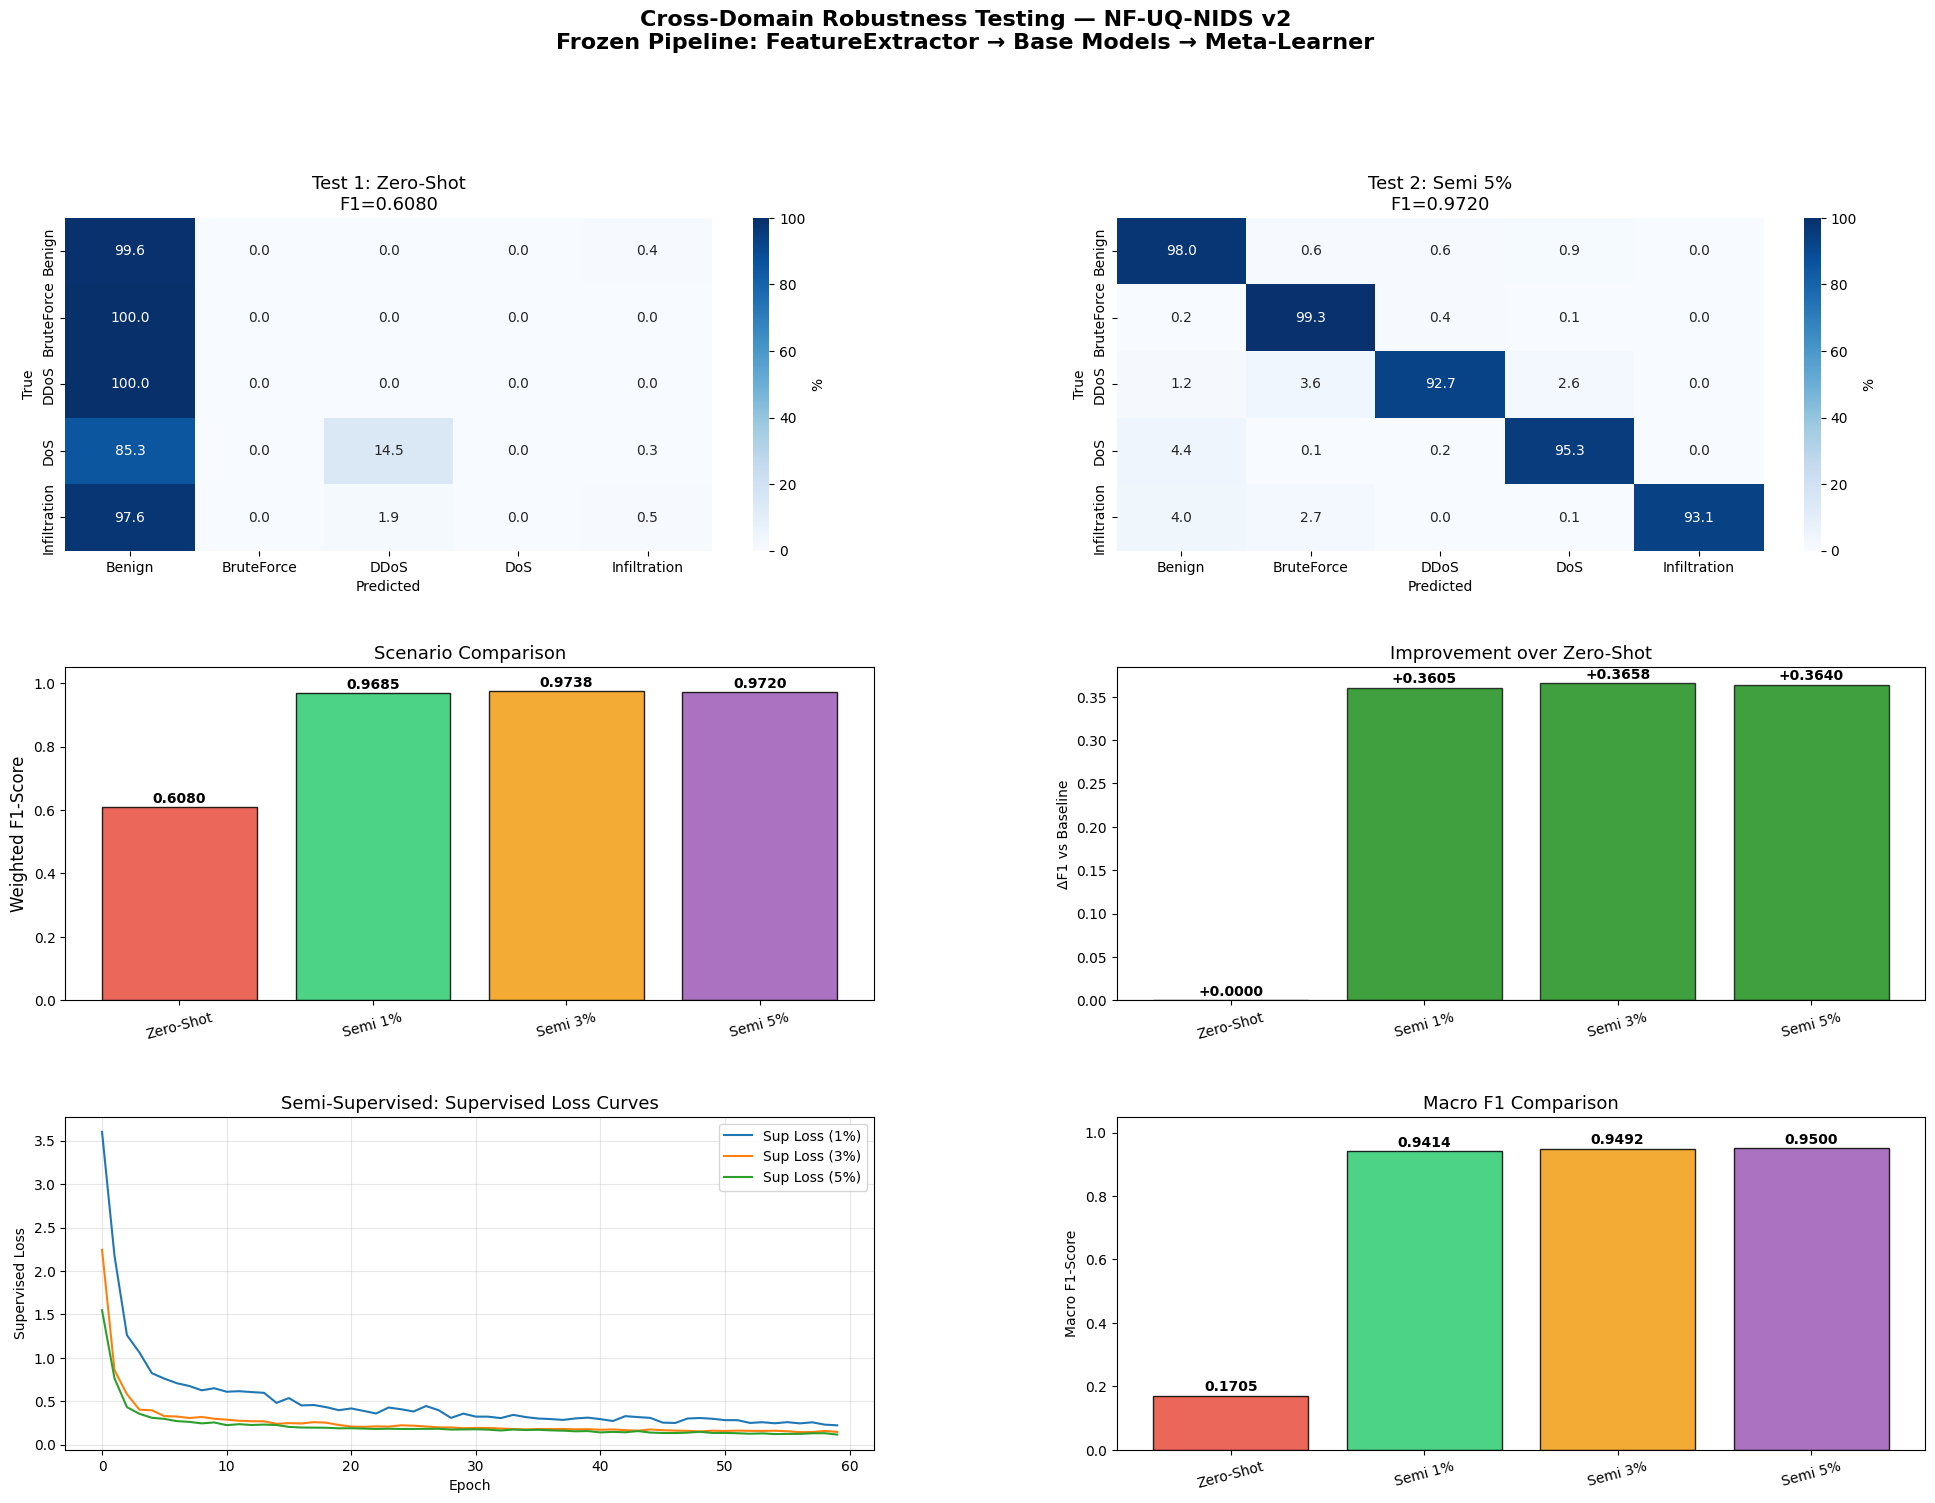

✓ Dashboard saved.


In [13]:
# ================================================================
# Visualization Dashboard
# ================================================================

fig = plt.figure(figsize=(24, 16))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

# Color scheme
colors = ['#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

# --- Row 1: Confusion Matrices (Zero-Shot and Best Semi-Supervised) ---
cm_scenarios = [
    ('Test 1: Zero-Shot', results_zs_test),
    (f'Test 2: Semi {int(LABEL_FRACTIONS[-1]*100)}%', results_semi[LABEL_FRACTIONS[-1]]),
]
for idx, (title, res) in enumerate(cm_scenarios):
    ax = fig.add_subplot(gs[0, idx])
    cm = res['confusion_matrix']
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=UNIFIED_CLASSES, yticklabels=UNIFIED_CLASSES,
                ax=ax, vmin=0, vmax=100, cbar_kws={'label': '%'})
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{title}\nF1={res["weighted_f1"]:.4f}', fontsize=13)

# --- Row 2 Left: Weighted F1 Bar Chart across scenarios ---
ax_bar = fig.add_subplot(gs[1, 0])
scenario_names = list(scenarios.keys())
f1_values = [scenarios[s]['weighted_f1'] for s in scenario_names]
short_names = ['Zero-Shot', 'Semi 1%', 'Semi 3%', 'Semi 5%'][:len(scenario_names)]
bars = ax_bar.bar(short_names, f1_values, color=colors[:len(f1_values)], edgecolor='black', alpha=0.85)
for bar, val in zip(bars, f1_values):
    ax_bar.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax_bar.set_ylabel('Weighted F1-Score', fontsize=12)
ax_bar.set_title('Scenario Comparison', fontsize=13)
ax_bar.set_ylim([0, 1.05])
ax_bar.tick_params(axis='x', rotation=15)

# --- Row 2 Right: Improvement over Baseline ---
ax_delta = fig.add_subplot(gs[1, 1])
improvements = [scenarios[s]['weighted_f1'] - baseline_f1 for s in scenario_names]
bar_colors = ['green' if d > 0 else 'red' for d in improvements]
bars_d = ax_delta.bar(short_names, improvements, color=bar_colors, edgecolor='black', alpha=0.75)
for bar, val in zip(bars_d, improvements):
    y_pos = bar.get_height() + 0.002 if val >= 0 else bar.get_height() - 0.015
    ax_delta.text(bar.get_x() + bar.get_width() / 2, y_pos,
                  f'{val:+.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax_delta.axhline(y=0, color='black', linewidth=0.8)
ax_delta.set_ylabel('ΔF1 vs Baseline')
ax_delta.set_title('Improvement over Zero-Shot', fontsize=13)
ax_delta.tick_params(axis='x', rotation=15)

# --- Row 3 Left: Semi-Supervised Training Curves ---
ax_curves = fig.add_subplot(gs[2, 0])
for frac in LABEL_FRACTIONS:
    pct = int(frac * 100)
    hist = results_semi[frac]['history']
    ax_curves.plot(hist['sup'], label=f'Sup Loss ({pct}%)', linestyle='-')
ax_curves.set_xlabel('Epoch')
ax_curves.set_ylabel('Supervised Loss')
ax_curves.set_title('Semi-Supervised: Supervised Loss Curves', fontsize=13)
ax_curves.legend()
ax_curves.grid(True, alpha=0.3)

# --- Row 3 Right: Macro F1 comparison ---
ax_macro = fig.add_subplot(gs[2, 1])
macro_values = [scenarios[s]['macro_f1'] for s in scenario_names]
bars_m = ax_macro.bar(short_names, macro_values, color=colors[:len(macro_values)],
                       edgecolor='black', alpha=0.85)
for bar, val in zip(bars_m, macro_values):
    ax_macro.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                  f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax_macro.set_ylabel('Macro F1-Score')
ax_macro.set_title('Macro F1 Comparison', fontsize=13)
ax_macro.set_ylim([0, 1.05])
ax_macro.tick_params(axis='x', rotation=15)

plt.suptitle('Cross-Domain Robustness Testing — NF-UQ-NIDS v2\n'
             'Frozen Pipeline: FeatureExtractor → Base Models → Meta-Learner',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig(os.path.join(MODEL_DIR, 'cross_domain_robustness_dashboard.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print("✓ Dashboard saved.")

In [14]:
# ================================================================
# Save All Results
# ================================================================

results_summary = {
    'scenarios': list(scenarios.keys()),
    'weighted_f1': [scenarios[s]['weighted_f1'] for s in scenarios],
    'macro_f1': [scenarios[s]['macro_f1'] for s in scenarios],
    'per_class_f1': np.array([scenarios[s]['per_class_f1'] for s in scenarios]),
    'unified_classes': UNIFIED_CLASSES,
    'v2_n_features': V2_N_FEATURES,
    'v3_n_features': v3_n_feat,
    'label_fractions': LABEL_FRACTIONS,
}

np.savez(os.path.join(MODEL_DIR, 'cross_domain_test_results.npz'), **results_summary)

print("="*60)
print("  ALL RESULTS SAVED")
print("="*60)
print(f"\nSaved to: {MODEL_DIR}/")
print(f"  - cross_domain_test_results.npz (metrics)")
print(f"  - cross_domain_robustness_dashboard.png (visualization)")
for frac in LABEL_FRACTIONS:
    pct = int(frac * 100)
    print(f"  - uqv2_extractor_semi_{pct}pct.pth (Semi-supervised {pct}%)")

print(f"\n{'='*60}")
print(f"  CONCLUSION")
print(f"{'='*60}")
print(f"\nBaseline (Zero-Shot):      Weighted F1 = {results_zs_test['weighted_f1']:.4f}")
best_semi_frac = max(results_semi.keys(), key=lambda f: results_semi[f]['weighted_f1'])
best_semi = results_semi[best_semi_frac]
print(f"Best Semi-Supervised ({int(best_semi_frac*100)}%): Weighted F1 = {best_semi['weighted_f1']:.4f} "
      f"({best_semi['weighted_f1'] - results_zs_test['weighted_f1']:+.4f})")
print(f"\n✓ Cross-domain robustness testing complete!")

  ALL RESULTS SAVED

Saved to: /home/huyho/earth_predict_env/Project/Model/Model_2017_IRM/
  - cross_domain_test_results.npz (metrics)
  - cross_domain_robustness_dashboard.png (visualization)
  - uqv2_extractor_semi_1pct.pth (Semi-supervised 1%)
  - uqv2_extractor_semi_3pct.pth (Semi-supervised 3%)
  - uqv2_extractor_semi_5pct.pth (Semi-supervised 5%)

  CONCLUSION

Baseline (Zero-Shot):      Weighted F1 = 0.6080
Best Semi-Supervised (3%): Weighted F1 = 0.9738 (+0.3658)

✓ Cross-domain robustness testing complete!
